## MAKE A BACKEND FOR MOVIE RECOMMENDATION ASSISTANT

In [1]:
#pip install -r ./requirements.txt

In [2]:
import numpy as np
import pandas as pd

In [3]:
import getpass
import os

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

In [4]:
df = pd.read_csv('./datas/cleaned_data.csv')
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Genre',
       'IMDB_Rating', 'Overview', 'Director', 'Star1', 'Star2', 'Star3',
       'Star4', 'No_of_Votes', 'Runtime_min', 'age_group'],
      dtype='str')

### CALL QDRANT VECTOR DB

In [4]:
os.environ["QDRANT_API_KEY"] = getpass.getpass("Enter your QDRANT API key: ")

In [5]:
os.environ["QDRANT_URL"] = getpass.getpass("Enter your QDRANT URL: ")

In [7]:
from langchain_openai import OpenAIEmbeddings
from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
client = QdrantClient(url=os.environ["QDRANT_URL"],api_key=os.environ.get("QDRANT_API_KEY"),
    timeout=120)

In [45]:
#Get all collection from Qdrant
colections_response = client.get_collections()

In [113]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qdrant = QdrantVectorStore.from_existing_collection(embedding=embeddings, collection_name='movies',
                                                    url=os.environ["QDRANT_URL"],
                                                    api_key=os.environ['QDRANT_API_KEY'])

In [57]:
results = qdrant.similarity_search('highest imdb ratings adult movies sorted by recent movies', k=5)
results

[Document(metadata={'_id': '921e5f94-3c66-4754-a43f-3e0263f958dc', '_collection_name': 'movies'}, page_content=" MovieName: Boogie Nights\n                    ReleasedYear: 1997\n                    IMDB_Rating: 7.9\n                    Synopsis: Back when sex was safe, pleasure was a business and business was booming, an idealistic porn producer aspires to elevate his craft to an art when he discovers a hot young talent.\n                    Director: Paul Thomas Anderson\n                    Actors: ('Mark Wahlberg', 'Julianne Moore', 'Burt Reynolds', 'Luis Guzmán')\n                    age_group: adults only\n"),
 Document(metadata={'_id': 'c3d7ea5f-f535-4c4c-a108-2c0cf661e9b4', '_collection_name': 'movies'}, page_content=" MovieName: The Big Short\n                    ReleasedYear: 2015\n                    IMDB_Rating: 7.8\n                    Synopsis: In 2006-2007 a group of investors bet against the US mortgage market. In their research they discover how flawed and corrupt the 

In [58]:
##### FOR PARSING ######### and checking
for res in results:
    print(f'Result Page Content: {res.page_content}\n Result Metadata:[{res.metadata}]')
    print('────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────')

Result Page Content:  MovieName: Boogie Nights
                    ReleasedYear: 1997
                    IMDB_Rating: 7.9
                    Synopsis: Back when sex was safe, pleasure was a business and business was booming, an idealistic porn producer aspires to elevate his craft to an art when he discovers a hot young talent.
                    Director: Paul Thomas Anderson
                    Actors: ('Mark Wahlberg', 'Julianne Moore', 'Burt Reynolds', 'Luis Guzmán')
                    age_group: adults only

 Result Metadata:[{'_id': '921e5f94-3c66-4754-a43f-3e0263f958dc', '_collection_name': 'movies'}]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Result Page Content:  MovieName: The Big Short
                    ReleasedYear: 2015
                    IMDB_Rating: 7.8
                    Synopsis: In 2006-2007 a group of investors bet against the US mortgage market. In their research they disco

### RAG + MULTIAGENT
- Onboarding agent (ask age and movies that the user likes) ✅
- Router agent (decide which agent do the query Retriever and Airing) ✅
- Airing agent (find which website you can find the movie at and which cinema you can go to asap)
- Supervisor agent (validator check output)
- Recommender agent
- Retriever agent (from Qdrant and VectorDB)
- Helper agent (floating agent: what I can do in this page)
- Sentiment and Diversity agent (To make the search more personal and not boring)

In [182]:
import json
import re
import time
from pprint import pprint
from IPython.display import display, Markdown
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.tools import tool
from typing import Annotated, Any, Literal, Optional
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langfuse.langchain import CallbackHandler
from langfuse import get_client
from ddgs import DDGS
llm = ChatOpenAI(model='gpt-4o-mini', temperature = 1)

In [ ]:
# Define Schema (how recommendationdata is stored and formatted)
class AgentState(TypedDict):
    onboarding_done: bool
    user_age: int
    age_rating_filter: list[str]
    preferred_genres: list[str]
    onboarding_answer: str
    answer: str
    tool_calls: list[dict] #identifier to track conversation across multiple interactions
    messages: list[BaseMessage]
    session_id: Optional[str] #conversation history

    route: Literal['retrieval', 'airing']
    next_agent:str

    retrieval_mode: Literal['exact', 'similar', 'discover']
    retrieval_target: str
    target_type: str
    retrieval_result: list[dict]
    retrieval_attempt: int
    retrieval_query: str

    sentiment_tone: str
    sentiment_keywords: list[str]
    sentiment_modifier: str
    diversity_modifier: str
    divergence_level: int

    seen_titles: list[str]

    recommendations: list[dict]
    recommendation_attempts: int

    airing_results: list[dict]
    airing_attempt: int

    validator_approved: bool
    validator_target: str
    validator_issues: list[str]    

In [ ]:
def _langfuse_cb(state):
    return CallbackHandler() #Logging LLM calls for Langfuse

In [94]:
# Add new tool_call in a list
def _log_tool(state: AgentState, tool_name:str, inputs: dict, output: Any) -> list:
    existing = state.get('tool_calls', [])
    return existing + [{'tool': tool_name, 'inputs': inputs, 'output': str(output)[:300]}]

In [81]:
def age_ratings(age:int) -> str:
    '''
    Map a user's age according to the most permissive content rating they could see
    Ratings follows:
    - Adults (17+): Can see everything including Adult content and Not Rated contents
    - Age 16: Can see everything, but NOT Adults only
    - Age 14-15: Can see everything, but NOT 16+ or Adults only
    - Age 8-13: Parental guidance and all ages content only
    - Age 0-7: Only All ages content
    '''
    if age == -1:
        return age_group == 'all ages'
    if age >= 17:
        age_group = ['all ages', 'parental guidance', '16 years old and above','14 years old and above', '13 years old and above', 'adults only', 'not rated']
    elif age ==16:
        age_group = ['all ages', 'parental guidance', '16 years old and above','14 years old and above', '13 years old and above']
    elif 14<= age <=15:
        age_group = ['all ages', 'parental guidance', '14 years old and above', '13 years old and above']
    elif 8<= age <=13:
        age_group = ['all ages', 'parental guidance', '13 years old and above']
    elif 5< age <=8:
        age_group = ['all ages', 'parental guidance']
    else:
        age_group = ['all ages']

    return age_group

In [189]:
# Onboarding agent: ask age and movies that user likes
def onboarding_agent(state: AgentState) -> dict:
    '''
    Collects two things from user before any recommendations can be made:
    1. **Age**: to recommend age-appropriate movies
    2. **Movie Preferences**: movie genres or movie titles that they like. Store in 'preferred_genres' and injected into every downstream retrieval query.

    Flow
    ----
    For RETURNING USER (user_age != -1 and preferred_genres already set):
        Skip onboarding entirely. Greet them and route straight to router_agent
    
    For NEW USER
    - First call (no age and movie preferences yet):
        Ask for ange AND movie preferences like in the 2000s, like this:
            'Hey there movie goers! Welcome to Your Movie recommendations. Before we start let me know your age and all your prefered movies/actors/directors'
        Set 'onboarding_done = False' and route to END so the pipeline waits for the user's reply.

    - Second call (user replied with age and movie preferences):
        Parse the latest HumanMessage to extract the age and movie preferences keywords
        Set 'onboaring_done = True' and route to router_agent so the normal pipeline continues.
        You can answer something like this:
            "You are 16 years old and likes: Action, Romance and Twilight. Let's continue"           
    '''
    cb = _langfuse_cb(state)

    # RETURNING USER
    is_returning = (state.get('user_age', -1) != -1 and bool(state.get('preferred_genres')))
    if is_returning:
        prefs_genres = ', '.join(state['preferred_genres'])
        welcome_prompt = ChatPromptTemplate.from_messages([SystemMessage(content=(f'''
            You are a friendly 2000s-styled movie assistant.
            The user is back! Greet them warmly in under 30 words, acknowled their *preferred_genre* and ask what they need today.''')),
            HumanMessage(content=(f'''User age: {state['user_age']}
                                  Preferences: {prefs_genres}'''))])
        response = llm.invoke(welcome_prompt.format_messages(), config={'callbacks': [cb]},)
        
        #Log the user's reply and output (parsed data)
        tool_calls = _log_tool(state, tool_name='onboarding_returnuser',
                                  inputs={'messages':[m.content for m in welcome_prompt]},
                                  output=response.content,)

        return{'onboarding_done': True,
               'onboarding_answer': response.content,
               'answer': response.content,
               'tool_calls': tool_calls,
               'messages':[AIMessage(content=response.content)],
               'next_agent': 'router_agent'}

    # WHEN THE APP JUST STARTED
    ## not any(isinstance(m, HumanMessage)) belum ada history conversation di state.message
    ### human message triggers the greeting
    if state['user_age'] == -1 and not state['onboarding_done'] and not any(isinstance(m, HumanMessage) for m in state['messages']):
        prompt = ChatPromptTemplate.from_messages([SystemMessage(content=(f'''
            You are a movie recommendation assistant starting a new conversation.
            You speak like a 2000s, gamers, friendly assistant.
            Your job is to ask the user age and what kind of movie they enjoy. It can be in genres or movie name or actors name or directors name.
            Keep the message under 60 words. Be engaging and conversational.
                                                                          ''')),
                                                    HumanMessage(content='Start onboarding conversation'),])
        response = llm.invoke(prompt.format_messages(), config={'callbacks': [cb]})
        greeting = response.content #extract greeting text
        return{'onboarding_done': False,
               'onboarding_answer': greeting,
               'answer': greeting,
               'messages': [AIMessage(content=greeting)],
               'next_agent': 'END',}

    human_reply=''
    #reversed = from [1,2,3] --> read [3,2,1] bisa aja nomor 3 itu AI message jadi ga pake state.messages[-1]
    for msg in reversed(state['messages']):
        #Find the most recent Human message
        if isinstance(msg, HumanMessage):
            human_reply = msg.content
            break
    extract_prompt = ChatPromptTemplate.from_messages([SystemMessage(content=(f'''
            Extract structured data from the user's message.
            Return ONLY valid JSON object with double quotes, no markdown, no explanation with exactly these keys:
                age: integer (the users age, or -1 if not mentioned)
                preferences: array of strings (genre names AND/or movie titles, actors and directors mentioned)
                example: "I am 22 years old and I love action and the matrix" -> {{'age': 22, 'preferences': ['action', 'the matrix']}}                                        
    ''')),
    HumanMessage(content=human_reply),])
    #Parse user's message
    raw = llm.invoke(extract_prompt.format_messages(), config = {'callbacks':[cb]})
    
    #Extract json from LLM response
    match = re.search(r'\{.*\}', raw.content, re.DOTALL)
    if match:
        #Dapet hasil extracted = {'age': 19, 'preferences': ['action', 'comedy']}
        extracted = json.loads(match.group())
    else:
        extracted = {'age': -1, 'preferences': []}

    #Convert age to int from str, with -1 as default value
    age: int = int(extracted.get('age', -1))
    prefs: list[str] = [str(p) for p in extracted.get('preferences',[])]

    if age == -1:
        follow_up_prompt = ChatPromptTemplate.from_messages([SystemMessage(content=(f'''
            The user did not mention their age. Ask them again and acknowledge any preferences stated.
                                                                                    ''')),
                                                            HumanMessage(content= human_reply),])
        fu = llm.invoke(follow_up_prompt.format_messages(), config={'callbacks': [cb]})
        return{'onboarding_done': False,
               'preferred_genres': prefs,
               'onboarding_answer': fu.content,
               'answer': fu.content,
               'messages': [AIMessage(content=fu.content)],
               'next_agent': 'END',}
    
    age_rating_ceiling = age_ratings(age)
    confirm_prompt = ChatPromptTemplate.from_messages([SystemMessage(content=(f'''
            The user has given their age and movie preferences.
            Write <30 words about: acknowledgement of their age and the content that will be recommended.
                                                                              ''')),
                                                        HumanMessage(content=f'User is {age} and likes {prefs}'),])
    confirm = llm.invoke(confirm_prompt.format_messages(), config={'callbacks': [cb]})
    
    #Log the user's reply and output (parsed data)
    tool_calls = _log_tool(state, 'onboarding_extract',
                           {'reply': human_reply},
                           {'age': age, 'age_rating_ceiling': age_rating_ceiling, 'preferences': prefs},)
    return{'onboarding_done': True,
           'user_age': age,
           'age_rating_filter': age_rating_ceiling,
           'preferred_genres': prefs,
           'onboarding_answer': confirm.content,
           'answer': confirm.content,
           'tool_calls': tool_calls,
           'messages': [AIMessage(content=confirm.content)],
           'next_agent': 'router_agent'}

Result still shows that the age can be changed easily when writing new age in chatbox. Must integrate with frontend to just change the age in user profile dashboard

In [138]:
#CHECK!
# state: AgentState = {'user_age': -1,
#                     'onboarding_done': True,
#                     'messages': [HumanMessage(content="I like action movies and 18 years old")],
#                     'session_id': "test-session",
#                     'tool_calls': []}
# result = onboarding_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'age_rating_filter': ['all ages',
                       'parental guidance',
                       '16 years old and above',
                       '14 years old and above',
                       '13 years old and above',
                       'adults only',
                       'not rated'],
 'answer': 'At 18, you’ll enjoy thrilling action movies filled with excitement '
           'and adventure! Get ready for adrenaline-pumping recommendations '
           'tailored just for you!',
 'messages': [AIMessage(content='At 18, you’ll enjoy thrilling action movies filled with excitement and adventure! Get ready for adrenaline-pumping recommendations tailored just for you!', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'router_agent',
 'onboarding_answer': 'At 18, you’ll enjoy thrilling action movies filled with '
                      'excitement and adventure! Get ready for '
                      'adrenaline-pumping recommendat

In [199]:
#Router Agent: Choose between Retrieval or Airing agent
def router_agent(state: AgentState) -> dict:
    cb = _langfuse_cb(state)
    
    #user context from onboarding agent
    prefs_genres = ','.join(state.get('preferred_genres', [])) or 'not specified'
    age_filter = ','.join(state.get('age_rating_filter', [])) or 'not specified'
    
    user_context = (f''' User age: {state.get('user_age', 'unknown')}
                            Allowed age ratings: {age_filter}
                            Preferred genres: {prefs_genres}
                            Onboarding answer: {state.get('onboarding_answer', '')}
                    ''')
    router_message = [SystemMessage(content=f'''
    You are a routing agent for a movie recommendation system.
    From user's onboarding profile, decide which agent to invoke next:
    - 'retrieval' = the user wants personalised movie recommendation
    - 'airing' = the user wants to know WHERE to legally watch a *specific* title in INDONESIA

    Rules (apply in order):
    - If the onboarding answer names of a specific movie AND expresses intent to watch / stream / find it -> 'airing'
    - If the user asks for suggestions, recommendations or 'what should I watch' -> 'retrieval'
    - When genuinely ambiguous -> default to 'retrieval'AIMessage

    NO NEED to apply age_rating_filter but pass it to the next agent
    Return ONLY valid JSON object with double quotes, no markdown, no explanation with exactly these keys:
        {{"route": "retrieval" | "airing", "reason": "<one concise sentence>"}}
                                            '''),
                        HumanMessage(content=user_context),]
    response = llm.invoke(router_message, config={'callbacks': [cb]},)

    #The kind to retrieve
    retrieve_prompt = f'''
        Classify the user intent to ONLY one of these:
    'exact': asking about a specific movie title, actor or director by name
        (ex. 'films about or starred by Jackie Chan' -> {{"mode":"exact", "target":"Jackie Chan", "target_type":"Actors"}}
            'the star war series movies for first timer' -> {{"mode": "exact", "target": "star war", "target_type":"MovieName"}}
            'recommend me other movies by Steven Spielberg' -> {{"mode": "exact", "target": "Steven Spielberg", "target_type": "Director"}})
    'similar': wants recommendation similar to something named
        (ex. 'I liked disney movies' -> {{"mode": "similar", "target":"disney", "target_type":"MovieName"}}
            'cartoon like zootopia' -> {{"mode": "similar", "target":"zootopia", "target_type":"MovieName"}})
    'discover': wants recommendation based on genres/mood ONLY, no specific references
        (ex. 'I like action movies' -> {{"mode":"discover", "target":"", "target_type":"none"}})
        Return ONLY valid JSON object with double quotes, no markdown, no explanation with exactly these keys:
        {{'mode': 'exact'|'similar'|'discover', 'target': '<name the specific name mentioned, else empty string>, 'target_type': 'title'|'actor'|'director'|'none'}}
    '''

    retrieve_rule = [SystemMessage(content=retrieve_prompt), HumanMessage(content=state.get('onboarding_answer', ''))]
    retrieve_rule_response = llm.invoke(retrieve_rule, config={'callbacks': [cb]})

    try:
        parse_retrieve_rule = json.loads(retrieve_rule_response.content.strip())
        retrieval_mode = parse_retrieve_rule.get('mode', 'discover')
        retrieval_target = parse_retrieve_rule.get('target', '')
        target_type = parse_retrieve_rule.get('target_type', '')
    except json.JSONDecodeError:
        retrieval_mode = 'discover'
        retrieval_target = ''
        target_type = 'none'

    #Log the user's reply and output (parsed data)
    update_tool_calls = _log_tool(state, tool_name='router_llm',
                                  inputs={'messages':[m.content for m in router_message]},
                                  output=response.content,)
    
    #Parsed data
    raw_text: str = response.content.strip()
    try:
        parsed: dict = json.loads(raw_text)
        route: str = parsed.get("route", "retrieval")
        reason: str = parsed.get("reason", "")
    except json.JSONDecodeError:
        route: str = "airing" if "airing" in raw_text.lower() else "retrieval"
        reason: str = "Fallback keyword parse(JSON decode failed)"
        parsed: dict = {"route": route, "reason": reason, "raw": raw_text}

    if route not in ('retrieval', 'airing'):
        route = "retrieval"
        reason = 'Unknown route so = retrieval'

    next_agent = "retrieval_agent" if route == "retrieval" else "airing_agent"
    
    return{'route': route,
           'messages': [AIMessage(content=f'{response.content} | {reason}')],
            'retrieval_mode': retrieval_mode,
           'retrieval_target': retrieval_target,
           'target_type': target_type,
           'tool_calls': update_tool_calls,
           'next_agent': next_agent}

In [200]:
# #CHECK!
# state: AgentState = {'user_age': 18,
#                     'preferred_genres': ['action'],
#                     'age_rating_filter': ['all ages', 'parental guidance', '16 years old and above','14 years old and above', '13 years old and above', 'adults only', 'not rated'],
#                     'onboarding_answer': 'recommend me a movie'}
# result = router_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'messages': [AIMessage(content='{"route": "retrieval", "reason": "The user is asking for movie recommendations."} | The user is asking for movie recommendations.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'retrieval_agent',
 'retrieval_mode': 'discover',
 'retrieval_target': '',
 'route': 'retrieval',
 'target_type': 'none',
 'tool_calls': [{'inputs': {'messages': ['\n'
                                         '    You are a routing agent for a '
                                         'movie recommendation system.\n'
                                         "    From user's onboarding profile, "
                                         'decide which agent to invoke next:\n'
                                         "    - 'retrieval' = the user wants "
                                         'personalised movie recommendation\n'
                                         "    - 'airing' = the user wants to "
                   

In [211]:
#Divergence so that it does not recommend that movie only
divergence_threshold = {0: (0,4),
                        1: (5,14),
                        2: (15,9999)}

divergence_info = {0: ('SAFE - stay very close to the user preferences and genres. No surprises'),
                   1: ('STRETCH - include 1-2 picks from adjacent genres or different eras/countries sharing similar moods or themes that the user enjoys'),
                   2: ('WILD - atleast half of the recommendations are suprising: cross-genre picks, international cinema, cult classics or hidden gems that the user unlikely have seen. The user has seen many recommendations so avoid repetition 5 times.')}

def divergence_level(seen_count:int) -> int:
    ''' Return 0,1 or 2 based on how many titles the user has seen'''
    for level, (low, hi) in divergence_threshold.items():
        if low <= seen_count <= hi:
            return level
    return 2 #kalau nilainya gede bgt ex. seen_count nya minus atau 10000

In [ ]:
#Retrieval agent: retrieve data from Qdrant vector db and Duckduckgo
def retrieval_agent(state: AgentState) -> dict:
    '''
    1. Builds an optimised search query from user's profile and validator feedback
    2. Search data from Qdrant (vector similarity) for semantically matching movies
    3. Searches DuckDuckGo for recent / trending semantically matches the user's query if the asked question is not in Qdrant
    4. Merges, deduplicate and age-filters results
    5. Increments retrieval_attempts and logs all tool calls
    '''
    cb = _langfuse_cb(state)
    attempt = state.get('retrieval_attempt', 0) + 1
    issues = state.get('validator_issues', [])
    prefs_genres = ', '.join(state.get('preferred_genres', [])) or 'not specified'

    query_message = [SystemMessage(content=f'''You are a search query builder for a movie vector database.
                                   Given the user profile, write <12 words of search query that will surface the most relevant movies.
                                   Focus on movies titles / directors / actors
                                   Do not include age or rating words.
                                   Return ONLY query string - no quotes, no explanation.
    '''), HumanMessage(content=f''' Preferred genres / interests: {prefs_genres}
                Onboarding answer: {state.get('onboarding_answer', '')} {f'previous retrieval issues to avoid: {'; '.join(issues)}' if issues else ""}''')]
    query_response = llm.invoke(query_message, config ={'callbacks':[cb]})
    search_query = query_response.content.strip().strip('"')

    if state.get('retrieval_mode') == 'exact':
        #FILTER BY METADATA
        target = state.get('retrieval_target', '')
        target_type = state.get('target_type', 'title')
        field_map = {'title': 'title',
                     'Actors': 'Actors',
                     'Director': 'Director',}
        field = field_map.get(target_type, 'title')

        qdrant_docs = qdrant.similarity_search(target, k=5, filter={'must': [{'key': field, 'match': {'value': target}}]})
        
        # Retrieve from DuckDuckGo
        ddg_scope = {'title': f'"{target}" movie',
                     'Actors': f'"{target}" actor filmography',
                     'Director': f'"{target}" director movies'}
        ddg_query = f'{ddg_scope.get(target_type, target)}'

    else:
        #FILTER THROUGH SIMILARITY OR DISCOVERY
        qdrant_docs = qdrant.similarity_search(search_query, k=5)
        qdrant_hits = []
        for doc in qdrant_docs:
            qdrant_hits.append({'title': doc.metadata.get('MovieName', doc.page_content[:60]),
                                'overview': doc.page_content[:30],
                                'rating': doc.metadata.get('age_group', ''),
                                'source': 'qdrant',})
    
        # Retrieve from DuckDuckGo
        ddg_hits = []
        tool_calls = state.get('tool_calls', [])
        if len(qdrant_hits) <= 5:
            ddg_query = f'best {prefs_genres}'

            time.sleep(1) #Duckduckgo needs time to search
            with DDGS() as ddgs:
                ddg_results = []

                for ddg_attempt in range(3):
                    try:
                        with DDGS() as ddgs:
                            ddg_results = list(ddgs.text(ddg_query, max_results=5, region="wt-wt", backend="lite"))
                        if ddg_results:
                            break
                    except Exception as e:
                        print("DDG error:", e)

                    time.sleep(1.5)  #Duckduckgo needs time to search

            for r in ddg_results:
                ddg_hits.append({'title': r.get('title', ''),
                                'overview': r.get('body', ''),
                                'rating': '',
                                'source': 'duckduckgo'})
            
            tool_calls = _log_tool({'tool_calls': state.get('tool_calls', [])},
                                'duckduckgo_search',
                                {'query': ddg_query},
                                f'{len(ddg_hits)} hits')
    
    #Merge + deduplicate + age-filter retrieval datas
    allowed_ratings = set(r.upper() for r in state.get('age_rating_filter', []))
    seen: set[str] = set()
    merged: list[dict] = []

    for hit in qdrant_hits + ddg_hits:
        key = re.sub(r'[^a-z0-9]', '', hit['title'].lower())
        if key in seen:
            continue
        seen.add(key)

        hit_rating = hit.get('rating', '').upper()
        if hit_rating and allowed_ratings and hit_rating not in allowed_ratings:
            continue
        merged.append(hit)

    new_calls = tool_calls if isinstance(tool_calls, list) else [tool_calls]
    all_tool_calls = state['tool_calls'] + [tc for tc in new_calls if tc not in state.get('tool_calls', [])]

    return{'retrieval_results': merged,
            'retrieval_query': search_query,
            'retrieval_attempts': attempt,
            'tool_calls': all_tool_calls,
            'messages': state['messages'] + [AIMessage(content=f'''
                [Retrieval] attempt {attempt}= {len(merged)} movies found via {search_query}''')],
            'next_agent': 'sentiment_agent',}
                    

Metadata still showed result not only zootopia

In [208]:
#CHECK!
# state: AgentState = {'preferred_genres': ['action'],
#                     'age_rating_filter': ['all ages', 'parental guidance', '16 years old and above','14 years old and above', '13 years old and above', 'adults only', 'not rated'],
#                     'onboarding_answer': 'I want to see zootopia newest movies',
#                     'retrieval_attempt': 0,
#                     'validator_issues': [],
#                     'tool_calls': [],
#                     'messages': []}
# result = retrieval_agent(state)
#pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'messages': [AIMessage(content='\n                [Retrieval] attempt 0= 10 movies found via Zootopia action movies, animated, directors, actors, adventure', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'sentiment_agent',
 'retrieval_attempts': 0,
 'retrieval_query': 'Zootopia action movies, animated, directors, actors, '
                    'adventure',
 'retrieval_results': [{'overview': ' MovieName: Zootopia\n         ',
                        'rating': '',
                        'source': 'qdrant',
                        'title': ' MovieName: Zootopia\n'
                                 '                    ReleasedYear: 2016\n'},
                       {'overview': ' MovieName: Zombieland\n       ',
                        'rating': '',
                        'source': 'qdrant',
                        'title': ' MovieName: Zombieland\n'
                                 '                    ReleasedYear: 200'},
           

In [213]:
#Sentiment agent
def sentiment_agent(state: AgentState) -> dict:
    '''Reads onboarding_answer + preferred_genres + seen_titles history.
    return sentiment_tone, sentiment_modifier, diversity_modifier
    sentiment_tone: one-word emotional tone
    sentiment_keywords: 3-6 salient taste phrases
    sentiment_modifier: preference directive for the recommendation prompt
    diversity_modifier: diversity directive saled by (SAFE, STRETCH or WILD) and divergence level 0,1 or 2
    '''

    cb = _langfuse_cb(state)
    issues = state.get('validator_issues', [])
    seen_titles: list[str] = state.get('seen_titles', [])
    seen_count = len(seen_titles)

    if seen_count <=4:
        divergence_level = 0
        divergence_label = 'SAFE'
        divergence_base = ('stay very close to the user\'s stated preferences and genres. No surprises')
    elif seen_count<=14:
        divergence_level = 1
        divergence_label = 'STRETCH'
        divergence_base = ('include 1-2 picks from adjacent genres or different eras/countries  sharing similar moods or themes that the user enjoys.')
    else:
        divergence_level = 2
        divergence_label = 'WILD'
        divergence_base =('atleast half of the recommendations are suprising: cross-genre picks, international cinema, cult classics or hidden gems that the user unlikely have seen. The user has seen many recommendations so avoid repetition 5 times')

    diversity_modifier = divergence_base
    issues_block = (f'Previous recommendation issues to fix: {''.join('- ' + i for i in issues) if issues else ''}')
    sentiment_prompt = [SystemMessage(content=(f'''You are a sentiment and preference analyser for a movie recommendation system
                                               Analyse the user onboarding answer and return ONLY JSON object with double quotes, no markdown, no explanation with exactly these keys:
                                                tone: string - one word describing emotional tone
                                                    (ex. excited, nostalgic, adventurous, picky, annoying)
                                                keywords: array - 3-6 salient words/phrases that reveal taste
                                                    (ex. "plot twists", "strong female lead", "pixar")
                                                modifier: string - one sentence preference directive for the recommendation agent
                                                    (ex. "I like plot twists and avoid slow-burn dramas"
                                                On a retry, adjust the modifier specifically to fix the listed issues.''')),
                        HumanMessage(content=(f''''User age: ' + str(state.get('user_age')) + 'Preferred genres: ' + ', '.join(state.get('preferred_genres', [])) + 'Onboarding answer: ' + state.get('onboarding_answer', '') + issues_block
                        '''))]
    response = llm.invoke(sentiment_prompt, config={'callbacks': [cb]})
    match  = re.search(r'\{.*\}', response.content, re.DOTALL)
    parsed = json.loads(match.group()) if match else {'tone': 'casual',
                                                      'keywords': state.get('preferred_genres', [])[:6],
                                                      'modifier': 'Recommend movies matching: ' + ', '.join(state.get('preferred_genres', [])) + '.'}
    
    tool_calls = _log_tool(state, 'sentiment_analysis',{
        'onboarding_answer': state.get('onboarding_answer', ''),
        'divergence_level': divergence_label,
        'seen_count': seen_count,},
        {**parsed, 'diversity_modifier': diversity_modifier[:120]},)
    
    return{'sentiment_tone': parsed.get('tone', 'casual'),
           'sentiment_keywords': parsed.get('keywords', []),
           'diversity_modifier': diversity_modifier,
           'divergence_level': divergence_level,
           'messages': state['messages'] + [AIMessage(content=f'''[Sentiment] tone={parsed.get('tone')}
                                                        divergence={divergence_label} (seen {seen_count} titles){parsed.get('modifier')}
                                                        '''.strip(), name='sentiment')],
           'tool_calls': tool_calls,
           'next_agent': 'recommendation_agent'}

In [215]:
#CHECK!
# state: AgentState = {'user_age': 25,
#                     'preferred_genres': ['action'],
#                     'onboarding_answer': 'I want to see zootopia newest movies',
#                     'seen_titles': [],
#                     'validator_issues': [],
#                     'tool_calls': [],
#                     'messages': []}
# result = sentiment_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'divergence_level': 0,
 'diversity_modifier': "stay very close to the user's stated preferences and "
                       'genres. No surprises',
 'messages': [AIMessage(content='[Sentiment] tone=neutral\n                                                        divergence=SAFE (seen 0 titles)Please provide information about user age and preferred genres clearly.', additional_kwargs={}, response_metadata={}, name='sentiment', tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'recommendation_agent',
 'sentiment_keywords': ['user age', 'preferred genres', 'onboarding answer'],
 'sentiment_tone': 'neutral',
 'tool_calls': [{'inputs': {'divergence_level': 'SAFE',
                            'onboarding_answer': 'I want to see zootopia '
                                                 'newest movies',
                            'seen_count': 0},
                 'output': "{'tone': 'neutral', 'keywords': ['user age', "
                           "'preferred genres', 'onboarding ans

In [220]:
#Recommendation agent: convert the retrieved movies to a personalized ranking list from sentimental_agent output
def recommendation_agent(state: AgentState) -> dict:
    '''Convert retrieval_results into a ranked, personalised list.
    sentiment_modifier and diversity_modifier are appended to the system prompt via strin concatenation with no .format() used anywhere
    
    After the LLM responds:
    - Hard age-rating filter runs as a safety net
    - Filter seen_titles so that the next session divergence level is computed correctly.'''
    
    cb = _langfuse_cb(state)
    attempt = state.get('recommendation_attempts', 0) + 1
    issues = state.get('validator_issues', [])
    modifier = state.get('sentiment_modifier', 'Match the user stated preferences')
    diversity_modifier = state.get('diversity_modifier', 'Stay close to stated preferences')
    genres = ', '.join(state.get('preferred_genres', [])) or 'not specified'
    age_ratings = ', '.join(state.get('age_rating_filter', [])) or 'all ages'
    results = state.get('retrieval_result', [])
    seen_titles = state.get('seen_titles', [])
    filtered_results = results
    movies_block = '\n'.join(f"{i+1}. {r['title']} [{r.get('rating', '?')}] - {r.get('overview', '')[:150]}"
                            for i, r in enumerate(filtered_results))
    prompt = ''' You are a movie recommendation agent.
    Convert retrieved movies into persoalised, ranked list that best matches the user age, preferences, emotional tone and any validator feedback.
    Rules:
    - Return JSON array of objects with double quotes, no markdown, no explanation with exactly these keys:
        {{"rank": int, "title": str, "source": str}}
        - Rank 1 = best match. Includes 3-7 movies
        - Never include movies who age_rating is not in the age_rating category
        - Sometimes recommend any title listed under 'Already seen'AIMessage
        - Reason must be directly reference the user stated preferences or tone
    '''
    recommendation_prompt = (f'''{prompt} Preference directive(what the user wants): {modifier}
                                Diversity directive" {diversity_modifier}''')
    issues_block = (f'Validator feedback from previous attempt (fix these): {chr(10).join('- ' + i for i in issues)}' if issues else'')
    user_content = f'''User age: {state.get('user_age')}
                    Allowed age ratings: {age_ratings}
                    Preferred genres / interests: {genres}
                    Sentiment tone: {state.get('sentiment_tone', 'casual')}
                    Sentiment keywords: {', '.join(state.get('sentiment_keywords', []))}
                    Divergence level: {['SAFE', 'STRETCH', 'WILD'][state.get('divergence_level', 0)]}
                    {issues_block}
                    Retrieved movies to rank:
                    {movies_block}
                    '''
    response = llm.invoke([SystemMessage(content=recommendation_prompt),
                           HumanMessage(content=user_content)], config={'callbacks': [_langfuse_cb(state)]},)
    
    match = re.search(r'\[.*\]', response.content, re.DOTALL)
    try:
        recs = json.loads(match.group()) if match else []
    except json.JSONDecodeError:
        recs = []

    allowed = set(r.upper() for r in state.get('age_rating_filter', []))
    if allowed:
        recs = [r for r in recs
                if not r.get('age_rating') or r['age_rating'].upper() in allowed]
        
    for i, rec in enumerate(recs):
        rec['rank'] = i + 1

    new_normalised = [ re.sub(r'[^a-z0-9]', '', r['title'].lower())
                        for r in recs]
    
    updated_seen_titles = seen_titles + [t for t in new_normalised if t not in set(seen_titles)]

    tool_calls = _log_tool(state, 'recommendation_llm',
        {'attempt': attempt,
            'pool_size': len(filtered_results),
            'seen_titles_count': len(seen_titles),
            'divergence': ['SAFE', 'STRETCH', 'WILD'][state.get('divergence_level', 0)],},
        str(len(recs)) + ' recommendations generated',)
 
    rec_summary = ' | '.join(str(r['rank']) + '. ' + r['title'] for r in recs[:5])
    
    return {'recommendations': recs,
            'recommendation_attempts': attempt,
            'seen_titles': updated_seen_titles,
            'tool_calls': tool_calls,
            'next_agent': 'validator_agent',
            'messages': state['messages'] + [AIMessage(content=('[Recommendation] attempt ' + str(attempt) + ' | '
                    'divergence=' + ['SAFE', 'STRETCH', 'WILD'][state.get('divergence_level', 0)] + ' | '
                    + rec_summary), name='recommendation',)],}

In [225]:
#CHECK!
# state: AgentState = {'user_age': 25,
#                     'preferred_genres': ['action'],
#                     'sentiment_tone': 'excited',
#                     'sentiment_keywords': ['mind-bending', 'tear-jerker'],
#                     'sentiment_modifier': 'Prioritize tear-jerker action',
#                     'diversity_modifier': 'Include 1-2 surprising picks',
#                     'diversity_level': 0,
#                     'seen_titles': [],
#                     'validator_issues': [],
#                     'retrieval_result': [
#                         {"title": "Inception", "rating": "13 and above", "overview": "Dreams within dreams"},
#                         {"title": "The Matrix", "rating": "13 and above", "overview": "Reality is fake"},
#                         {"title": "Interstellar", "rating": "13 and above", "overview": "Space and time"}
#                     ],
#                     'tool_calls': [],
#                     'messages': []}
# result = sentiment_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'divergence_level': 0,
 'diversity_modifier': "stay very close to the user's stated preferences and "
                       'genres. No surprises',
 'messages': [AIMessage(content='[Sentiment] tone=neutral\n                                                        divergence=SAFE (seen 0 titles)I have specific preferences based on my age and preferred genres.', additional_kwargs={}, response_metadata={}, name='sentiment', tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'recommendation_agent',
 'sentiment_keywords': ['user age', 'preferred genres', 'onboarding answer'],
 'sentiment_tone': 'neutral',
 'tool_calls': [{'inputs': {'divergence_level': 'SAFE',
                            'onboarding_answer': '',
                            'seen_count': 0},
                 'output': "{'tone': 'neutral', 'keywords': ['user age', "
                           "'preferred genres', 'onboarding answer'], "
                           "'modifier': 'I have specific preferences based on "
     

In [233]:
LEGAL_PLATFORMS = {
        'netflix': 'Netflix',
        'disney+': 'Disney+',
        'disney plus': 'Disney+',
        'vidio': 'Vidio',
        'mola': 'Mola',
        'bioskop online': 'Bioskop Online',
        'amazon prime': 'Amazon Prime Video',
        'prime video': 'Amazon Prime Video',
        'apple tv': 'Apple TV+',
        'hbo go': 'HBO Go',
        'max': 'Max',
        'catchplay': 'CatchPlay+',
        'viu': 'Viu',
        'iflix': 'iFlix',
        'youtube': 'YouTube',
        'google play': 'Google Play Movies',
        'itunes': 'iTunes',
    }

In [234]:
#Airing agent:
def airing_agent(state: AgentState) -> dict:
    '''
    Searches for LEGAL streaming availability of a specific movie/actor/director in INDONESIA ONLY via DuckDuckGo

    Flow:
    1. Build a targeted DDG query from retrieval target + target_type
    2. Search DDG with retry logic
    3. Filter to known legal Indonesian platforms only
    4. Validate retry and validator issues to refine query
    5. Feeds to validator agent to check they are legal, age appropriate and atleast 1 movie is found
    '''

    cb = _langfuse_cb(state)
    attempt = state.get('airing_attempts', 0) + 1
    issues = state.get('validator_issues', [])
    target = state.get('retrieval_target', state.get('onboarding_answer', ''))
    target_type = state.get('target_type', 'title')

    base_query_map = {
    "title": f"{target} streaming Indonesia legal watch online",
    "actor": f"{target} movies streaming Indonesia legal watch online",
    "director": f"{target} films streaming Indonesia legal watch online",}
    base_query = base_query_map.get(target_type, target + ' streaming Indonesia')

    if issues:
        issue_text = ' '.join(issues).lower()
        if 'non-legal' in issue_text or 'unrecognised' in issue_text:
            base_query = target + ' Netflix OR Vidio OR "Disney+" OR "Amazon Prime" Indonesia'
        elif 'no airing results' in issue_text or 'too narrow' in issue_text:
            base_query = target + ' where to watch Indonesia streaming'

    ddg_results = []
    time.sleep(1)
    for ddg_attempt in range(3):
        try:
            with DDGS() as ddgs:
                ddg_results = list(ddgs.text(
                    base_query,
                    max_results=8,
                    region='id-id',
                    backend='lite',))
            if ddg_results:
                break
        except Exception as e:
            print('DDG airing error:', e)
        time.sleep(1.5)
    
    tool_calls = _log_tool(state, 'airing_duckduckgo',
        {'query': base_query, 'attempt': attempt}, str(len(ddg_results)) + ' raw results',)
    
    airing_results: list[dict] = []
 
    for r in ddg_results:
        title_text = r.get('title', '')
        body_text  = r.get('body',  '')
        url        = r.get('href',  '')
        combined   = (title_text + ' ' + body_text).lower()
 
        detected_platform = None
        for keyword, platform_name in LEGAL_PLATFORMS.items():
            if keyword in combined:
                detected_platform = platform_name
                break
 
        if not detected_platform:
            continue
 
        if any(w in combined for w in ['available', 'watch now', 'stream now', 'now streaming']):
            availability = 'Available'
        elif any(w in combined for w in ['not available', 'unavailable', 'coming soon']):
            availability = 'Not available'
        else:
            availability = 'Check platform'
 
        airing_results.append({'title':        target,
                                'platform':     detected_platform,
                                'url':          url,
                                'availability': availability,
                                'snippet':      body_text[:200],})
 
    seen_platforms: set[str] = set()
    deduped: list[dict] = []
    for r in airing_results:
        if r['platform'] not in seen_platforms:
            seen_platforms.add(r['platform'])
            deduped.append(r)
 
    new_calls     = tool_calls if isinstance(tool_calls, list) else [tool_calls]
    all_tool_calls = state.get('tool_calls', []) + [
        tc for tc in new_calls if tc not in state.get('tool_calls', [])]
 
    platform_summary = (', '.join(r['platform'] for r in deduped)
        if deduped else 'no legal platforms found')
 
    return {
        'airing_results': deduped,
        'airing_attempt': attempt,
        'tool_calls':     all_tool_calls,
        'next_agent':     'supervisor_agent',
        'messages': state['messages'] + [AIMessage(content=f'[Airing] attempt {attempt} | {len(deduped)} platforms | {platform_summary}', name='airing')]}

In [236]:
#CHECK!
# state: AgentState = {
#     "retrieval_target": "Inception",
#     "target_type": "title",
#     "validator_issues": [],
#     "messages": [],
#     "tool_calls": []
# }
# result = airing_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'airing_attempt': 1,
 'airing_results': [{'availability': 'Check platform',
                     'platform': 'Netflix',
                     'snippet': 'Key Takeaways: Watch Inception Online for '
                                'FreeSign up for NordVPN by going to its '
                                'website and grabbing a 76% discounted '
                                'plan.Log in to Netflix and stream ‘Inception‘',
                     'title': 'Inception',
                     'url': 'https://www.cloudwards.net/where-to-watch-inception/'},
                    {'availability': 'Check platform',
                     'platform': 'YouTube',
                     'snippet': "Videos you watch may be added to the TV's "
                                'watch history and influence TV '
                                'recommendations. To avoid this, cancel and '
                                'sign in to YouTube on your computer.',
                     'title': 'Inception',
          

In [229]:
#Supervisor agent: validate movie list. Age appropriate content, validate answer is already according to the query
def supervisor_agent(state: AgentState) -> dict:
    f'''Validates output from EITHER pipeline:
 
    Retrieval pipeline  -> validates recommendations from recommendation_agent
    Airing pipeline     -> validates platform results from airing_agent
 
    Checks performed:
      1. Completeness    — minimum number of results returned
      2. Age-rating      — no result exceeds age_rating_filter
      3. Seen-titles     — no already-seen title slipped through
      4. Relevance       — LLM checks results match the user request
                           (only runs if checks 1-3 all pass)
      5. Airing legality — platforms are legal Indonesian services only
 
    target escalation (first issue wins):
      retrieval problems  -> target = "retrieval"
      recommendation problems -> target = "sentiment"
    '''
    cb    = _langfuse_cb(state)
    route = state.get('route', 'retrieval')
 
    issues: list[str] = []
    target = 'done'
    recs = state.get('recommendations', [])

    allowed_ratings = set(r.upper() for r in state.get('age_rating_filter', []))
    
    # TOO little recommendation
    if len(recs) < 3:
        issues.append(f'''Too few recommendations returned ({str(len(recs))}.
                            'Retrieval likely returned poor results - broaden the search query.''')
        target = 'retrieval'

    #Age rating not the same
    violating = [r['title'] for r in recs if r.get('age_rating') and r.get('age_rating', '').upper() not in allowed_ratings]
    if violating:
        issues.append(f'''Age-rating violation: {', '.join(violating)} exceed allowed ratings '
                        ({', '.join(allowed_ratings)}). Fix in recommendation ranking.''')
        if target == 'done':
            target = 'sentiment'
 
    if not issues:
        retrieval_mode   = state.get('retrieval_mode',   'discover')
        retrieval_target = state.get('retrieval_target', '')
        prefs            = ', '.join(state.get('preferred_genres', []))
        rec_titles       = ', '.join(r.get('title', '') for r in recs)
        relevance_focus = (f'The user asked specifically about: {retrieval_target}.'
                            f'ALL recommendations must relate directly to this entity.'
                            if retrieval_mode == 'exact'
                            else f'The user prefers: {prefs}.')

        val_prompt = [SystemMessage(content=f''' You are a movie recommendation validator.
                        Check if the recommendations are relevant to the user's request.
                        Return ONLY valid JSON: {{"approved": true|false, "issues": ["issue1", "issue2"]}}
                        If approved, issues must be an empty array.
                        Be strict about exact-mode requests - if the user asked for a specific 
                        title/actor/director, ALL recommendations must relate directly to that entity.'''.strip()),
                    HumanMessage(content=f'''{relevance_focus} Recommended titles: {rec_titles} Sentiment modifier applied: {state.get('sentiment_modifier', '')}'''.strip()),]
        val_response = llm.invoke(val_prompt, config={'callbacks': [cb]})

        match  = re.search(r'\{.*\}', val_response.content, re.DOTALL)
        parsed = {'approved': False, 'issues': ['Validator LLM failed to respond correctly']}

        if not parsed.get('approved', True):
            issues.extend(parsed.get('issues', []))
            target = 'sentiment'

    if route == 'airing':
        airing_results: list[dict] = state.get('airing_results', [])
 
        if len(airing_results) < 1:
            issues.append(f'''No airing results found. DuckDuckGo search may be too narrow - retry with broader query.'''.strip())
            target = 'retrieval'
 
        LEGAL_PLATFORMS = {'netflix', 'disney+', 'disney plus', 'vidio', 'mola',
            'bioskop online', 'amazon prime', 'prime video', 'apple tv',
            'hbo go', 'max', 'catchplay', 'viu', 'iflix','youtube', 'google play', 'itunes',}
        illegal = [r.get('platform', '') for r in airing_results
            if r.get('platform') and not any(p in r['platform'].lower() for p in LEGAL_PLATFORMS)]
        if illegal:
            issues.append(f'''Non-legal or unrecognised platforms: {', '.join(illegal)}.
                            Only show verified legal Indonesian streaming platforms.''')
            if target == 'done':
                target = 'retrieval'

    approved = len(issues) == 0
    if approved:
        target = 'done'
 
    tool_calls = _log_tool(state, 'validator',
        {'route':     route,
        'attempt':   state.get('retrieval_attempts', 0),
        'rec_count': len(state.get('recommendations', [])),},
        {'approved': approved, 'issues': issues, 'target': target},)
 
    status = 'APPROVED' if approved else 'REJECTED -> retry ' + target
 
    return {'validator_approved': approved,
            'validator_target': target,
            'validator_issues': issues,
            'tool_calls': tool_calls,
            'next_agent': 'end' if approved else target,
            'messages': state['messages'] + [AIMessage(
                 content=f'''[Validator] {status} | issues: {str(issues if issues else 'none')}''',name='validator')],}

In [230]:
#Check
# state: AgentState = {"route": "retrieval",
#                     "recommendations": [
#                         {"title": "Inception", "age_rating": "PG-13"},
#                         {"title": "Interstellar", "age_rating": "PG-13"},
#                         {"title": "The Matrix", "age_rating": "R"},
#                     ],
#                     "age_rating_filter": ["PG-13"],
#                     "preferred_genres": ["sci-fi"],
#                     "retrieval_mode": "discover",
#                     "messages": [],}
# result = supervisor_agent(state)
# pprint(result)

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


{'messages': [AIMessage(content='[Validator] REJECTED -> retry sentiment | issues: ["Age-rating violation: The Matrix exceed allowed ratings \'\\n                        (PG-13). Fix in recommendation ranking."]', additional_kwargs={}, response_metadata={}, name='validator', tool_calls=[], invalid_tool_calls=[])],
 'next_agent': 'sentiment',
 'tool_calls': [{'inputs': {'attempt': 0, 'rec_count': 3, 'route': 'retrieval'},
                 'output': '{\'approved\': False, \'issues\': ["Age-rating '
                           'violation: The Matrix exceed allowed ratings '
                           "'\\n                        (PG-13). Fix in "
                           'recommendation ranking."], \'target\': '
                           "'sentiment'}",
                 'tool': 'validator'}],
 'validator_approved': False,
 'validator_issues': ['Age-rating violation: The Matrix exceed allowed ratings '
                      "'\n"
                      '                        (PG-13). Fi

In [232]:
def validator_edge(state: AgentState, ) -> Literal['retrieval_agent', 'sentiment_agent', 'end']:
    '''
    Approved by supervisor
    target = retrieval + retrieval_attempts < 2 -> retrieval_agent
    target = sentiment + recommendation_attempt < 2 -> sentiment_agent
    '''
    if state.get("validator_approved", False):
        return "end"
 
    target = state.get("validator_target", "done")
 
    if target == "retrieval" and state.get("retrieval_attempts", 0) < 2:
        return "retrieval_agent"
 
    if target == "sentiment" and state.get("recommendation_attempts", 0) < 2:
        return "sentiment_agent"
 
    return "end"

In [ ]:
#Chatterbox_agent


LANGGRAPH

In [250]:
from typing import Literal, Optional
from langchain_core.messages import BaseMessage
from langfuse.langchain import CallbackHandler
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# Define Schema
class AgentState(TypedDict):
    onboarding_done: bool
    user_age: int
    age_rating_filter: list[str]
    preferred_genres: list[str]
    onboarding_answer: str
    answer: str
    tool_calls: list[dict]
    messages: list[BaseMessage]
    session_id: Optional[str]

    route: Literal['retrieval', 'airing']
    next_agent: str

    retrieval_mode: Literal['exact', 'similar', 'discover']
    retrieval_target: str
    target_type: str
    retrieval_result: list[dict]
    retrieval_attempt: int
    retrieval_query: str

    sentiment_tone: str
    sentiment_keywords: list[str]
    sentiment_modifier: str
    diversity_modifier: str
    divergence_level: int

    seen_titles: list[str]

    recommendations: list[dict]
    recommendation_attempts: int

    airing_results: list[dict]
    airing_attempt: int

    validator_approved: bool
    validator_target: str
    validator_issues: list[str]    

# Router to retrieve/airing
def router_retrieve_airing(state: AgentState) -> Literal['retrieval_agent', 'airing_agent']:
    return 'airing_agent' if state.get('route') == 'airing' else 'retrieval_agent'

def validation(state: AgentState) -> Literal['retrieval_agent', 'sentiment_agent', 'airing_agent', 'wait_node']:
    """Validation always goes to wait_node - never directly to END"""
    route = state.get('route', 'retrieval')
    target = state.get('validator_target', 'done')
    
    # If validation approved, go to wait_node
    if state.get('validator_approved', False):
        return 'wait_node'

    # Retry for airing flow
    if route == 'airing':
        if state.get('airing_attempt', 0) < 2:
            return 'airing_agent'
        return 'wait_node'
    
    # Retry for retrieval flow
    if target == 'retrieval' and state.get('retrieval_attempt', 0) < 2:
        return 'retrieval_agent'
 
    if target == 'sentiment' and state.get('recommendation_attempts', 0) < 2:
        return 'sentiment_agent'
    
    return 'wait_node'

def after_wait_node(state: AgentState) -> Literal['router_agent', 'end']:
    """Wait node checks user input - only END ends the graph"""
    messages = state.get('messages', [])
    if messages and hasattr(messages[-1], 'content'):
        last_content = messages[-1].content.lower().strip()
        if last_content == 'end':
            return 'end'
    
    # Reset state for new query
    state['validator_approved'] = False
    state['recommendations'] = []
    state['airing_results'] = []
    state['retrieval_result'] = []
    
    return 'router_agent'

def graphy(onboarding_agent, router_agent, retrieval_agent, sentiment_agent, recommendation_agent, airing_agent, supervisor_agent) -> StateGraph:
    g = StateGraph(AgentState)
    
    g.add_node('onboarding_agent', onboarding_agent)
    g.add_node('router_agent', router_agent)
    g.add_node('retrieval_agent', retrieval_agent)
    g.add_node('sentiment_agent', sentiment_agent)
    g.add_node('recommendation_agent', recommendation_agent)
    g.add_node('airing_agent', airing_agent)
    g.add_node('supervisor_agent', supervisor_agent)
    g.add_node('wait_node', lambda state, config=None: state)

    g.add_edge(START, 'onboarding_agent')
    g.add_edge('onboarding_agent', 'router_agent')
    
    g.add_conditional_edges('router_agent', router_retrieve_airing, 
        {'retrieval_agent': 'retrieval_agent', 'airing_agent': 'airing_agent'})
    
    g.add_edge('retrieval_agent', 'sentiment_agent')
    g.add_edge('sentiment_agent', 'recommendation_agent')
    g.add_edge('recommendation_agent', 'supervisor_agent')
    
    g.add_edge('airing_agent', 'supervisor_agent')

    g.add_conditional_edges('supervisor_agent', validation, {
        'retrieval_agent': 'retrieval_agent',
        'sentiment_agent': 'sentiment_agent',
        'airing_agent': 'airing_agent',
        'wait_node': 'wait_node'})
    
    g.add_conditional_edges('wait_node', after_wait_node, {
        'router_agent': 'router_agent',
        'end': END})
    
    return g.compile()

def run_graph(state: AgentState, movie_graph) -> dict:
    cb = CallbackHandler()
    return movie_graph.invoke(state, config={'callbacks': [cb]},)

def initial_state(session_id:str = 'new') -> AgentState:
    return AgentState(onboarding_done= False,
        user_age = -1,
        age_rating_filter = [],
        preferred_genres = [],
        onboarding_answer = '',
        answer = '',
        tool_calls = [],
        messages = [],
        session_id = session_id,
        route = 'retrieval',
        next_agent = 'onboarding_agent',
        retrieval_mode = 'discover',
        retrieval_target = '',
        target_type = 'none',
        retrieval_result = [],
        retrieval_attempt = 0,
        retrieval_query = '',
        sentiment_tone = '',
        sentiment_keywords = [],
        sentiment_modifier = '',
        diversity_modifier = '',
        divergence_level = 0,
        seen_titles = [],
        recommendations = [],
        recommendation_attempts = 0,
        airing_results = [],
        airing_attempt = 0,
        validator_approved = False,
        validator_target = 'done',
        validator_issues = [],)

In [ ]:
from typing import Annotated, Literal, Optional
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
from langfuse.langchain import CallbackHandler
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from IPython.display import Image, display

# Define Schema
class AgentState(TypedDict):
    onboarding_done: bool
    user_age: int
    age_rating_filter: list[str]
    preferred_genres: list[str]
    onboarding_answer: str
    answer: str
    tool_calls: Annotated[list, lambda x, y: y]
    messages: Annotated[list, add_messages]
    session_id: Optional[str]
    route: Literal['retrieval', 'airing']
    next_agent: str
    retrieval_mode: Literal['exact', 'similar', 'discover']
    retrieval_target: str
    target_type: str
    retrieval_result: Annotated[list, lambda x, y: y]
    retrieval_attempt: int
    retrieval_query: str
    sentiment_tone: str
    sentiment_keywords: Annotated[list, lambda x, y: y]
    sentiment_modifier: str
    diversity_modifier: str
    divergence_level: int
    seen_titles: Annotated[list, lambda x, y: y]
    recommendations: Annotated[list, lambda x, y: y]
    recommendation_attempts: int
    airing_results: Annotated[list, lambda x, y: y]
    airing_attempt: int
    validator_approved: bool
    validator_target: str
    validator_issues: Annotated[list, lambda x, y: y]
    waiting_for_input: bool  # New flag to indicate if graph is waiting for user input

def get_last_user_message(state: AgentState) -> str:
    """Extract the last user message from conversation history"""
    messages = state.get('messages', [])
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            return msg.content
    return ""

def build_query_message(state: AgentState) -> list[BaseMessage]:
    """Build the query message using both onboarding answer and last user message"""
    prefs_genres = state.get('preferred_genres', [])
    onboarding_answer = state.get('onboarding_answer', '')
    last_user_message = get_last_user_message(state)
    issues = state.get('validator_issues', [])
    
    user_context = f"""Preferred genres / interests: {prefs_genres}
Onboarding answer: {onboarding_answer}
Last user message: {last_user_message}"""
    
    if issues:
        user_context += f"\nprevious retrieval issues to avoid: {'; '.join(issues)}"
    
    query_message = [
        SystemMessage(content="You are a search query builder. Return ONLY a short search query (<12 words). Focus on movie titles, directors, or actors. No quotes, no explanation."),
        HumanMessage(content=user_context)
    ]
    
    return query_message

def onboard_router(state: AgentState) -> str:
    """After onboarding, go to router or wait_node if user wrote END"""
    messages = state.get('messages', [])
    if messages:
        last_msg = messages[-1]
        if isinstance(last_msg, HumanMessage):
            last_content = last_msg.content.lower().strip()
            if last_content == 'end':
                return 'wait_node'
    
    if state.get('onboarding_done'):
        return 'router_agent'
    return 'wait_node'

def router_retrieve_airing(state: AgentState) -> str:
    """Route to retrieval or airing"""
    return 'airing_agent' if state.get('route') == 'airing' else 'retrieval_agent'

def validation(state: AgentState) -> str:
    """Validation routing - after processing, go to wait_node to pause"""
    # Check for END command
    messages = state.get('messages', [])
    if messages:
        last_msg = messages[-1]
        if isinstance(last_msg, HumanMessage):
            last_content = last_msg.content.lower().strip()
            if last_content == 'end':
                return 'end'
    
    # Always go to wait_node after validation to pause execution
    # The graph will stop here and wait for next user input
    return 'wait_node'

def wait_node(state: AgentState) -> dict:
    """
    Wait node - this is the termination point for each graph run.
    The graph will stop here and return control to the application.
    """
    print("📌 Wait node: Graph paused. Waiting for next user input...")
    # Set flag to indicate we're waiting for input
    return {"waiting_for_input": True}

def graphy(onboarding_agent, router_agent, retrieval_agent, sentiment_agent, 
           recommendation_agent, airing_agent, supervisor_agent) -> StateGraph:
    """Build the graph"""
    g = StateGraph(AgentState)
    
    # Add nodes
    g.add_node("onboarding_agent", onboarding_agent)
    g.add_node("router_agent", router_agent)
    g.add_node("retrieval_agent", retrieval_agent)
    g.add_node("sentiment_agent", sentiment_agent)
    g.add_node("recommendation_agent", recommendation_agent)
    g.add_node("airing_agent", airing_agent)
    g.add_node("supervisor_agent", supervisor_agent)
    g.add_node("wait_node", wait_node)
    
    # Set entry point
    g.set_entry_point("onboarding_agent")
    
    # Add conditional edges
    g.add_conditional_edges(
        "onboarding_agent", 
        onboard_router,
        {
            "router_agent": "router_agent",
            "wait_node": "wait_node"
        }
    )
    
    g.add_conditional_edges(
        "router_agent", 
        router_retrieve_airing,
        {
            "retrieval_agent": "retrieval_agent",
            "airing_agent": "airing_agent"
        }
    )
    
    # Sequential edges
    g.add_edge("retrieval_agent", "sentiment_agent")
    g.add_edge("sentiment_agent", "recommendation_agent")
    g.add_edge("recommendation_agent", "supervisor_agent")
    g.add_edge("airing_agent", "supervisor_agent")
    
    # After supervisor, always go to validation then wait_node
    g.add_edge("supervisor_agent", "wait_node")
    
    # wait_node goes to END (graph pauses here)
    g.add_edge("wait_node", END)
    
    return g.compile()

def run_graph(state: AgentState, movie_graph) -> dict:
    """Run the graph once - will stop at wait_node"""
    try:
        cb = CallbackHandler()
        return movie_graph.invoke(state, config={'callbacks': [cb]})
    except Exception as e:
        print(f"Error: {e}")
        return movie_graph.invoke(state)

def continue_graph(state: AgentState, movie_graph, user_message: str) -> dict:
    """
    Continue the graph execution with new user input.
    This should be called after each time the graph stops at wait_node.
    """
    # Add the new user message to state
    state["messages"].append(HumanMessage(content=user_message))
    state["waiting_for_input"] = False
    
    # Reset validation flag for new request
    state["validator_approved"] = False
    state["validator_target"] = "done"
    
    # Run the graph again
    return run_graph(state, movie_graph)

def initial_state(session_id: str = 'new') -> AgentState:
    """Initialize the agent state"""
    return {
        "onboarding_done": False,
        "user_age": -1,
        "age_rating_filter": [],
        "preferred_genres": [],
        "onboarding_answer": "",
        "answer": "",
        "tool_calls": [],
        "messages": [],
        "session_id": session_id,
        "route": "retrieval",
        "next_agent": "onboarding_agent",
        "retrieval_mode": "discover",
        "retrieval_target": "",
        "target_type": "none",
        "retrieval_result": [],
        "retrieval_attempt": 0,
        "retrieval_query": "",
        "sentiment_tone": "",
        "sentiment_keywords": [],
        "sentiment_modifier": "",
        "diversity_modifier": "",
        "divergence_level": 0,
        "seen_titles": [],
        "recommendations": [],
        "recommendation_attempts": 0,
        "airing_results": [],
        "airing_attempt": 0,
        "validator_approved": False,
        "validator_target": "done",
        "validator_issues": [],
        "waiting_for_input": False,
    }

Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 


Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 
Authentication error: Langfuse client initialized without public_key. Client will be disabled. Provide a public_key parameter or set LANGFUSE_PUBLIC_KEY environment variable. 



STARTING CONVERSATION

--- Turn 1: User asks for movies ---
📋 Onboarding complete
🗺️ Routing...
🔍 Retrieving movies...
😊 Analyzing sentiment...
🎬 Generating recommendations...
👀 Validating...
📌 Wait node: Graph paused. Waiting for next user input...
Recommendations: [{'title': 'Action Movie 1'}, {'title': 'Action Movie 2'}]

--- Turn 2: User asks for airing shows ---
📋 Onboarding complete
🗺️ Routing...
📺 Getting airing shows...
👀 Validating...
📌 Wait node: Graph paused. Waiting for next user input...
Airing results: [{'show': "Tonight's Show"}]

--- Turn 3: User ends conversation ---
📋 Onboarding complete
📌 Wait node: Graph paused. Waiting for next user input...
Conversation ended


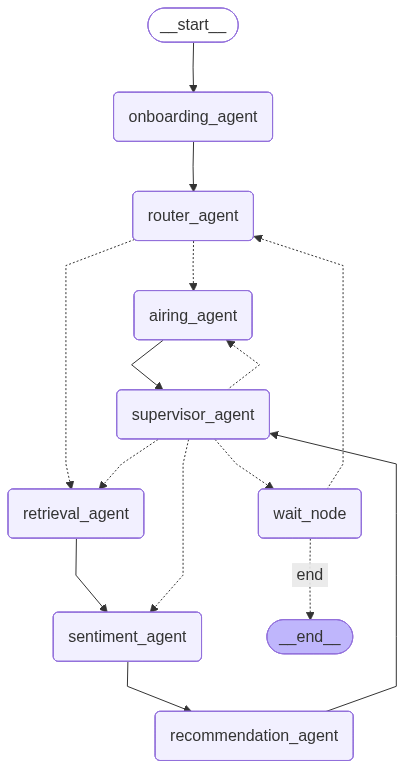

In [251]:
from IPython.display import Image, display
def onboarding_agent(state): return state
def router_agent(state): return state
def retrieval_agent(state): return state
def sentiment_agent(state): return state
def recommendation_agent(state): return state
def airing_agent(state): return state
def validation_agent(state): return state

compiled_graph = graphy(onboarding_agent, router_agent, retrieval_agent, sentiment_agent, 
                        recommendation_agent, airing_agent, validation_agent)

display(Image(compiled_graph.get_graph().draw_mermaid_png()))